# 你好，图像分类

本教程是 OpenVINO™ 的基础介绍，展示了如何使用图像分类模型进行推理。

本教程使用了来自 [Open Model Zoo](https://github.com/openvinotoolkit/open_model_zoo/) 的预训练 [MobileNetV3 模型](https://github.com/openvinotoolkit/open_model_zoo/blob/master/models/public/mobilenet-v3-small-1.0-224-tf/README.md)。有关 OpenVINO IR 模型的创建方法，请参阅 [TensorFlow 转 OpenVINO](../tensorflow-classification-to-openvino/tensorflow-classification-to-openvino.ipynb) 教程。

#### 目录：

- [导入](#Imports)
- [下载模型和数据样本](#Download-the-Model-and-data-samples)
- [选择推理设备](#Select-inference-device)
- [加载模型](#Load-the-Model)
- [加载图像](#Load-an-Image)
- [执行推理](#Do-Inference)

### 安装说明

这是一个自包含的示例，仅依赖于其自身的代码。

我们建议在虚拟环境中运行此笔记本。您只需要一个 Jupyter 服务器即可开始。  
详细信息请参阅 [安装指南](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide)。

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/hello-world/hello-world.ipynb" />

In [1]:
# Install required packages
%pip install -q "openvino>=2023.1.0" opencv-python tqdm "matplotlib>=3.4"

Note: you may need to restart the kernel to use updated packages.


## 导入
[返回顶部 ⬆️](#Table-of-contents:)

In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import openvino as ov

# Fetch `notebook_utils` module
import requests


if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )

    open("notebook_utils.py", "w").write(r.text)

from notebook_utils import download_file, device_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("hello-world.ipynb")

## 下载模型和数据样本
[返回顶部 ⬆️](#Table-of-contents:)

In [3]:
base_artifacts_dir = Path("./artifacts").expanduser()

model_name = "v3-small_224_1.0_float"
model_xml_name = f"{model_name}.xml"
model_bin_name = f"{model_name}.bin"

model_xml_path = base_artifacts_dir / model_xml_name

base_url = "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/models/mobelinet-v3-tf/FP32/"

if not model_xml_path.exists():
    download_file(base_url + model_xml_name, model_xml_name, base_artifacts_dir)
    download_file(base_url + model_bin_name, model_bin_name, base_artifacts_dir)
else:
    print(f"{model_name} already downloaded to {base_artifacts_dir}")

v3-small_224_1.0_float.xml:   0%|          | 0.00/294k [00:00<?, ?B/s]

v3-small_224_1.0_float.bin:   0%|          | 0.00/4.84M [00:00<?, ?B/s]

## 选择推理设备
[返回顶部 ⬆️](#Table-of-contents:)

从下拉列表中选择设备，使用 OpenVINO 运行推理

In [4]:
device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

## 加载模型
[返回顶部 ⬆️](#Table-of-contents:)

In [5]:
core = ov.Core()
model = core.read_model(model=model_xml_path)
compiled_model = core.compile_model(model=model, device_name=device.value)

output_layer = compiled_model.output(0)

## 加载一张图片
[返回顶部 ⬆️](#Table-of-contents:)

coco.jpg:   0%|          | 0.00/202k [00:00<?, ?B/s]

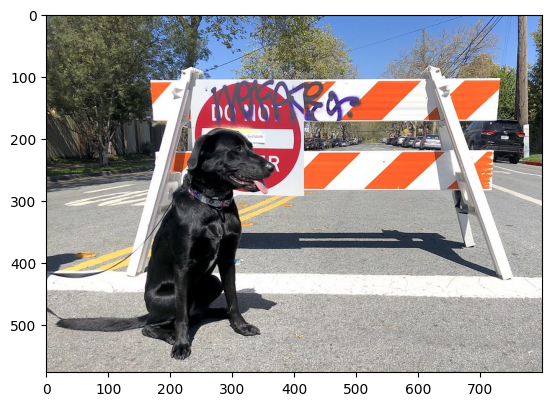

In [6]:
# Download the image from the openvino_notebooks storage
image_filename = Path("data/coco.jpg")

if not image_filename.exists():
    download_file(
        "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco.jpg",
        directory="data",
    )

# The MobileNet model expects images in RGB format.
image = cv2.cvtColor(cv2.imread(filename=str(image_filename)), code=cv2.COLOR_BGR2RGB)

# Resize to MobileNet image shape.
input_image = cv2.resize(src=image, dsize=(224, 224))

# Reshape to model input shape.
input_image = np.expand_dims(input_image, 0)
plt.imshow(image);

## 进行推理
[返回顶部 ⬆️](#Table-of-contents:)

In [7]:
result_infer = compiled_model([input_image])[output_layer]
result_index = np.argmax(result_infer)

In [8]:
imagenet_filename = Path("data/imagenet_2012.txt")

if not imagenet_filename.exists():
    download_file(
        "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/datasets/imagenet/imagenet_2012.txt",
        directory="data",
    )

imagenet_classes = imagenet_filename.read_text().splitlines()

imagenet_2012.txt:   0%|          | 0.00/30.9k [00:00<?, ?B/s]

In [9]:
# The model description states that for this model, class 0 is a background.
# Therefore, a background must be added at the beginning of imagenet_classes.
imagenet_classes = ["background"] + imagenet_classes

imagenet_classes[result_index]

'n02099267 flat-coated retriever'